# REASON CATEGORIZATION
This notebook parses the database files consisting of chat logs between residents and assistants. It attempts to analyze the chats and categorize the reason for not renewing leases into one of four categories.
1. Rent Price
2. Maintenance Issues
3. Life Changes (Jobs, Moving)
4. Questions (Uncertain chat logs)
Arriving at these categories follows a multistep analysis process studing semantic similarities between sentences utilizing sentence transformers modules. This particular notebook utilizes `gte-base`.

## Dependencies
- pandas
- numpy
- matplotlib
- sklearn
- pytorch
- torchvision
- transformers
- sentence_transformers

## Features
A rough three step analysis is conducted in order to understand the categories at play in the housing market renewal decisions. All semantic encodings are done using `gte-base`. Sentences are formed for each `'resident_id`' by concatenating all of their chat logs into one big sentence. This likely introduces extraneous and misleading information into the sentences. `'user_msgs'` contains all the concatenated sentences.
### k-Means Clustering
A k-means clustering analysis is conducted first to break the text into rough groups. k = 10 and k = 4 are attempted. From this the rough groups outlined above are identified.
### Projection Analysis
2D plots are analyzed along the dimensions corresponding to the categories outlined above. We find strong correlation between all of these categories, though some are slightly less correlated. We also attempt to check the happiness of the sentences and the confusion of the sentences. This shows some correlation with the categories, but not always. This is a good starting point for future PCA analyses.

Further analysis of projecting the sentences into category embeddings (defined by encoding example sentences for each category). It shows that all four reasons are strongly present in all sentences, indicating perhaps there is redundancy in our choice of categories, as we saw from the strong correlation.

### Cosine Similarity Scores

Cosine similarity is calculated for its popular usage to determine semantic similarities between embeddings. The consine similarities between each chat log and the representative category example is calculated and the chat logs for each resident is assigned a category based on the most similar category. We find that this is almost always rent pricing. The total count is presented here:
```
--- TOTAL CATEGORY COUNT ---
reason
Rent           363
Life             6
Question         5
Maintenance      2
```
The results are saved as `category_predictions.csv`.

In [1]:
# This is an ugly hot-fix in order to get gte-base to work on Intel-based Macs
# Credits to Google Gemini
import sys
import types
import PIL.Image
import PIL

# 1. FIX PILLOW (The PILLOW_VERSION error)
PIL.PILLOW_VERSION = PIL.__version__
PIL.Image.PILLOW_VERSION = PIL.__version__

import torchvision

# 2. FIX TORCHVISION IO (The 'cannot import name io' error)
# We create a fake module and attach it to torchvision so the import succeeds
if not hasattr(torchvision, 'io'):
    mock_io = types.ModuleType("io")
    torchvision.io = mock_io
    sys.modules["torchvision.io"] = mock_io
    print("Successfully patched torchvision.io for Intel Mac compatibility.")

# 3. FIX INTERPOLATION (The NEAREST_EXACT/Resampling errors)
class FakeInterpolation:
    NEAREST = 0; BILINEAR = 2; BICUBIC = 3; LANCZOS = 1; HAMMING = 4; BOX = 5
    NEAREST_EXACT = 0; TRIANGLE = 2
if not hasattr(torchvision.transforms, 'InterpolationMode'):
    torchvision.transforms.InterpolationMode = FakeInterpolation

Successfully patched torchvision.io for Intel Mac compatibility.


In [2]:
### Imports ####
import sqlite3
import json
import pandas as pd
import numpy as np
 
# Import transformer models
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

/Users/henry/anaconda3/envs/transformer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data Preprocessing
Minimal work is done processing the data. Only `'resident_id'` and `'unit_number'` from residents data, `'renewal_decision'` from offers data, and the chat data is required. This code builds upon the last notebook's code by concatenating all messages into one sentence and storing that in the dataframe. New here is `'user_msgs'` consisting of concatenated sentences.

In [ ]:
# Functions to parse the data
''' 
Create a dataframe from db and json file. Does some initial
processing of the json file as follows:
    - Counts the number of messages each user sends.
    - Concatenates all of the user messages
These features are appended onto the residents information.
args:
    db_path (str): path to db file
    json_path (str): path to json file
returns:
    chats (df) : All the data including resident_id,
                 user_msgs, and renewal_decision
'''
def read_data(db_path, json_path, is_train = True):
    # Reads either test or training data
    train = "_train" if is_train else "_test"

    # Parse the .db file
    conn = sqlite3.connect(db_path)
    residents = pd.read_sql_query(f"SELECT * FROM residents{train}", conn)
    maintenance = pd.read_sql_query(f"SELECT * FROM maintenance_history{train}", conn)
    offers = pd.read_sql_query(f"SELECT * FROM renewal_offers{train}", conn)

    # Parse the json file
    with open(json_path, 'r') as f:
        chats = json.load(f)

    chat_features = []
    for res in chats:
        res_id = int(res['resident_id'])
        # Count the number of messages the user sends
        user_msgs = [[m['message'] for m in res['conversation'] if m['role'] == 'user']]
        user_msg = " ".join(str(msg) for msg in user_msgs)
        msg_count = len(user_msgs)
        chat_features.append({'resident_id' : res_id, 'msg_count' : msg_count, 'user_msgs' : user_msg})
    chat_df = pd.DataFrame(chat_features)

    # Merge chat data with residents data and merge offers to have renewal_decision
    chat_df = residents.merge(chat_df, on = 'resident_id', how = 'left')
    chat_df['msg_count'] = chat_df['msg_count'].fillna(0)
    chat_df = chat_df.merge(offers, left_on = 'unit_number', right_on = 'unit')

    return chat_df

'''
This function performs k-means clustering starting from initial
categories chosen by the user for some language transfer model.
args:
    model (SentenceTransformer) : A sentence transformer model.
    catergory_examples ({str : str}) : Dictionary of category
        definitions to an example sentence expressing the 
        sentiment of the category.
return
    clustered_sentences ([[str]]) : List of lists of sentences
        in each cluster.
    cluster_assignments ([int]) : Cluster index for each element.
'''
def k_means_clustering(embeddings, messages, n_clusters):
    # Perform the k-means clustering
    kmeans = KMeans(n_clusters = n_clusters)
    kmeans.fit(embeddings)

    cluster_assignments = kmeans.labels_
    clustered_sentences = [[] for _ in range(n_clusters)]

    for sentence_id, cluster_id in enumerate(cluster_assignments):
        clustered_sentences[cluster_id].append(messages.iloc[sentence_id])
    
    print("--- CLUSTERING RESULTS ---")
    for i, cluster in enumerate(clustered_sentences):
        print(f"Cluster {i}: {cluster}")

    return clustered_sentences, cluster_assignments


''' 
Projects word embedding into two user defined axes based on chosen
word axes.
args:
    model (sentencetransformer): Sentence transformer model
    embeddings (array): embeddings to project and plot
    x_sentences ([str, str]) : Two opposite sentences to define the x axis
    y_sentences ([str, str]) : Two opposite sentences to define the y axis
    titles ([str, str, str]) : Plot title, x axis label, y axis label
    savefile (str) : File path to save figure, None if nothing is to be saved
returns:

'''
def plot_2d_projection(model, embeddings, x_sentences, y_sentences, titles = None, savefile = None):
    plt.clf()
    x_embedding = model.encode(x_sentences, normalize_embeddings = True)
    y_embedding = model.encode(y_sentences, normalize_embeddings = True)

    x = x_embedding[1] - x_embedding[0]
    y = y_embedding[1] - y_embedding[0]

    x_vals = embeddings @ x
    y_vals = embeddings @ y

    plt.scatter(x_vals, y_vals)
    if titles is not None:
        plt.title(titles[0])
        plt.xlabel(titles[1])
        plt.ylabel(titles[2])
    if savefile is not None:
        plt.savefig(savefile)
    plt.show()

''' 
Computes the cosine similarity between two embeddings.
args:
    embeddings (array): sentence embeddings to categorize
    category_embeddings (array) : Embedding of categories
return:
    best_match_idx (array) : One dimensional array of category
        index of each sentence in embedding.
'''
def categorize_cosine_similarity(embedding, category_embeddings, verbose = False):
    cosine_scores = cos_sim(embedding, category_embeddings)
    best_match_idx = np.argmax(cosine_scores, axis = 1)
    if verbose:
        for i in range(best_match_idx.shape[0]):
            print(f"{i}: {best_match_idx[i]} -> {cosine_scores[i, best_match_idx[i]]:.4f}")
    return best_match_idx


In [4]:
# Load the Data from file
chats = read_data(
    "research-practical-main/data/resident_database.db", 
    "research-practical-main/data/conversations_train.json", True)

In [5]:
# Load the gte-base model
gte_model = SentenceTransformer('thenlper/gte-base')

### Analysis
Only the data pertaining to non-renewals are of interest to us. Begin by taking `'user_msgs'` consisting of concatenated sentences and calculate the embedding.

In [6]:
# Compute the sentence embeddings
chats_norenew = chats[chats['renewal_decision'] == 0].reset_index(drop = True)
chats_embedding = gte_model.encode(chats_norenew['user_msgs'], normalize_embeddings = True)

#### K-MEANS CLUSTERING
A 10-means clustering analysis is done to identify categories. We settle on the four described above.

In [7]:
'''
This performs a 10 cluster k-means clustering. From the results the categories seem to be as follows:
1. Rent Increase
2. Moving and New Job + Rent Increase
3. Maintenance + Rent Increase
4. Moving + Rent Increase
5. Maintenance + Rent Increase
6. Life Changes and Circumstances + Pricing (Cannot Make it Work)
7. Maintenance + Rent Increase
8. Question about details and rates
9. Circumstances, Jobs - More hesitance (Not sure, thinking a lot)
10. Personal Situation, Maintenance, Rent Increase
For reference: https://www.census.gov/library/stories/2023/09/why-people-move.html
'''
'''
Inspired by the last analysis there seems to be 4 main categories:
1. Rent Increase
2. Maintenance Issues
3. Personal Reasons (Work, Moving, Circumstances)
4. Questions with no reason given
'''
chats_clustered, chats_assigned = k_means_clustering(chats_embedding, chats_norenew['user_msgs'], 10)

--- CLUSTERING RESULTS ---
Cluster 0: ['["Hi Elise, thanks for checking in with me. I did see the offer—the new rate is definitely something to think about. I\'m weighing a few things right now, but I\'m not sure renewing is really in the cards.", "Well, to be honest, the jump in rent is a lot for me right now. I\'ve also been evaluating my situation with work, and it seems like moving might be the best fit. So, I won\'t be renewing my lease."]', '["Hello, Elise. I am reaching out to gather complete information on any potential 12-month lease renewal options for my apartment. I want to fully understand what\'s on the table before making my decision, although I will say right off the bat that the new rental rate seems quite steep compared to my original agreement. In light of how much the rent is going up for this unit, and considering how it fits into my current financial picture, I will not be renewing my lease. Still, I would appreciate all official details so I can make sure I\'m in

#### PROJECTION ANALYSIS
A 2D projection is done for each category combination as well as "happiness" and "confusion". Strong correlation between categories is found indicating some redundancies.

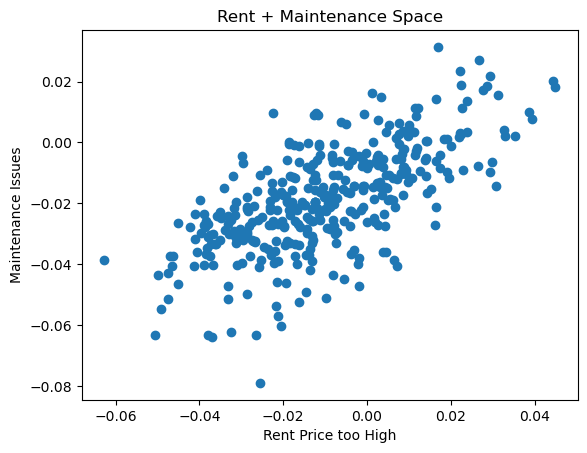

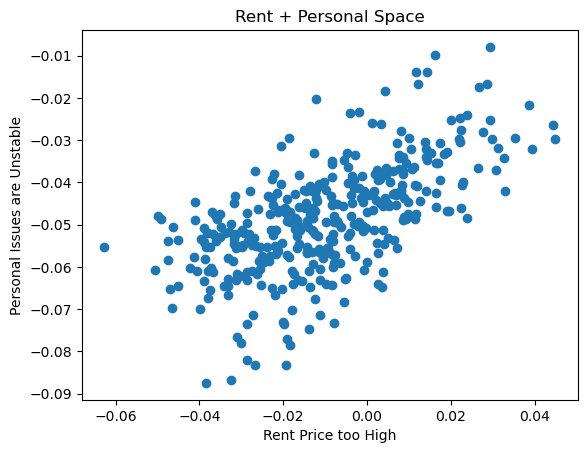

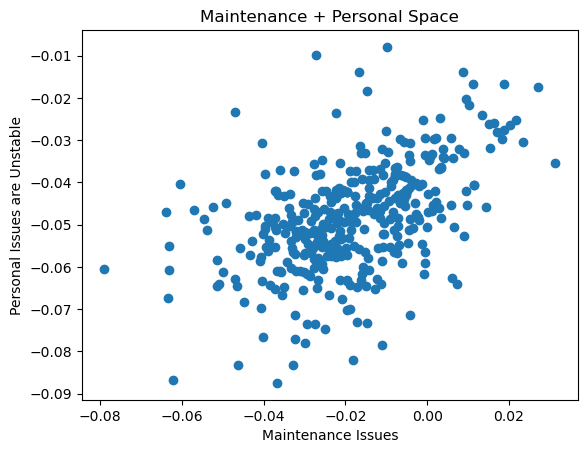

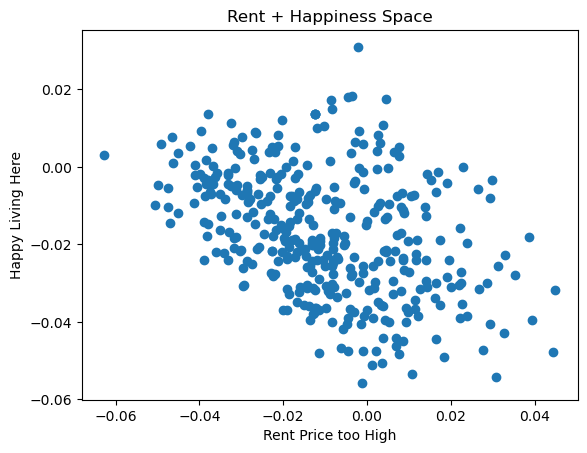

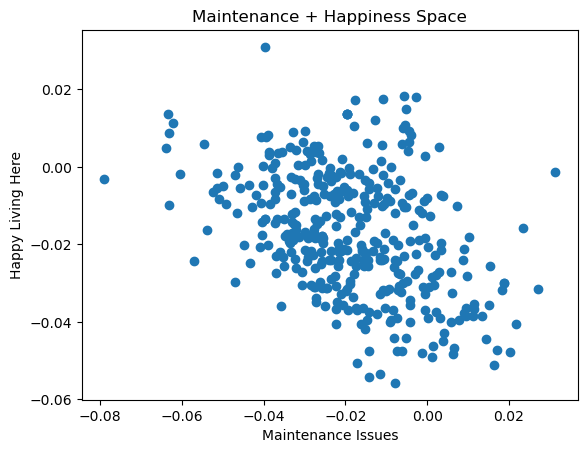

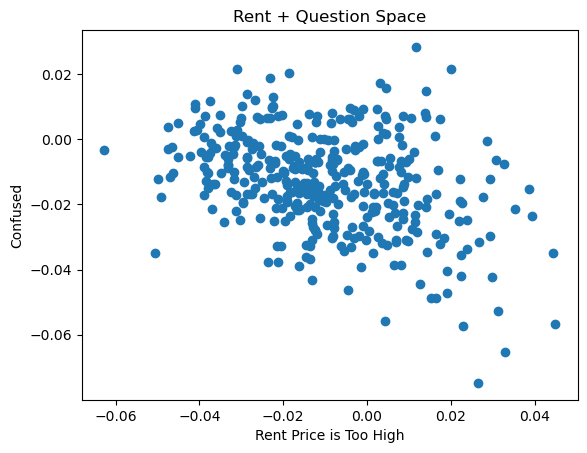

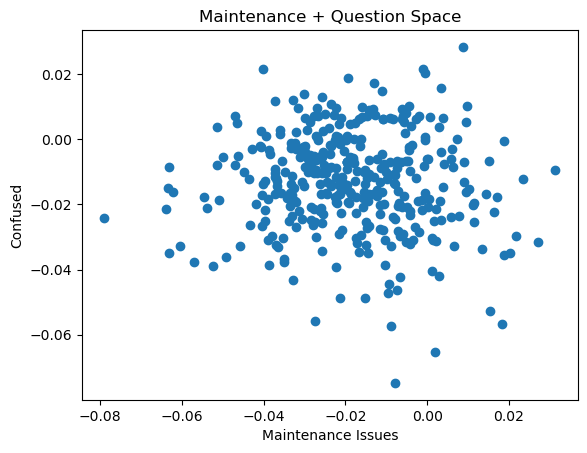

In [18]:
# Plot a 2D projection of the embedding space
rent_sentences = ["The rent price increase is too high", "The rent price is very reasonable"]
maintenance_sentences = ["The maintenance issues are too much and repair requests are too slow", "This place is well maintained with no issues"]
personal_sentences = ["My circumstances have changed and I have to move for a new job", "My life is stable and happy"]
happy_sentences = ["I enjoy living here", "I hate this place"]
question_sentences = ["What are the details?", "I know what I want."]
plot_2d_projection(gte_model, chats_embedding, rent_sentences, maintenance_sentences, titles = ["Rent + Maintenance Space", "Rent Price too High", "Maintenance Issues"], savefile = "figures/emb2d_rent_maint")
plot_2d_projection(gte_model, chats_embedding, rent_sentences, personal_sentences, titles = ["Rent + Personal Space", "Rent Price too High", "Personal Issues are Unstable"], savefile = "figures/emb2d_rent_personal")
plot_2d_projection(gte_model, chats_embedding, maintenance_sentences, personal_sentences, titles = ["Maintenance + Personal Space", "Maintenance Issues", "Personal Issues are Unstable"], savefile = "figures/emb2d_maint_personal")
plot_2d_projection(gte_model, chats_embedding, rent_sentences, happy_sentences, titles = ["Rent + Happiness Space", "Rent Price too High", "Happy Living Here"], savefile = "figures/emb2d_rent_happy")
plot_2d_projection(gte_model, chats_embedding, maintenance_sentences, happy_sentences, titles = ["Maintenance + Happiness Space", "Maintenance Issues", "Happy Living Here"], savefile = "figures/emb2d_maint_happy")
plot_2d_projection(gte_model, chats_embedding, rent_sentences, question_sentences, titles = ["Rent + Question Space", "Rent Price is Too High", "Confused"], savefile = "figures/emb2d_rent_question")
plot_2d_projection(gte_model, chats_embedding, maintenance_sentences, question_sentences, titles = ["Maintenance + Question Space", "Maintenance Issues", "Confused"], savefile = "figures/emb2d_maint_question")

In [9]:
# Run this with 4 clusters for the four categories above
chats_clustered, chats_assigned = k_means_clustering(chats_embedding, chats_norenew['user_msgs'], 4)

--- CLUSTERING RESULTS ---
Cluster 0: ['["Thanks for reaching out, Elise. I will not be renewing my lease. The renewal rent increase is just too much for me right now, and to be honest, I\'ve had a couple maintenance issues that took longer than I expected to get handled."]', "['Thank you, Elise, for the reminder. At this moment, I have reviewed the renewal offer that was sent to me. I do not have additional questions, but I wish to notify you that I will not be renewing my lease.', 'Certainly. The reason is primarily the increase in rent presented in the renewal terms. Unfortunately, with my current circumstances, it is not feasible for me to accommodate the higher monthly cost. I have also taken into account some personal matters which necessitate my relocation.', 'Thank you, Elise. Kindly forward the move-out instructions and inform me of any action required on my end. I appreciate your assistance during this process.']", "['Hi Elise, I will not be renewing my lease. The new rent is

#### Category Embedding
Category embeddings are defined for each chosen category (Rent, Maintenance, Life, Question) consisting of an eample sentence used to calculate the embedding for each category. This is used for semantic similarity analysis.

In [10]:
# Make clear category definitions for these 4 categories in the form of a dictionary
# {category : example sentence}

category_definitions_and_examples = {
    "Rent" : "The rent price is too high.",
    "Maintenance" : "There are too many maintenance issues and repairs are slow.",
    "Life" : "My circumstances and job have changed and I need to move.",
    "Question" : "I'm not sure. What are the details?"
}

category_examples = list(category_definitions_and_examples.values())
category_def = list(category_definitions_and_examples.keys())
category_ex_embedding = gte_model.encode(category_examples, normalize_embeddings = True)

#### EMBEDDING PROJECTION
The projection of each category onto each sentence is conducted. Almost all of the sentences are consistent (and high) in terms of overlap with each category, with rent winning out easily. This disappointing as we would want distict categories that change between sentences.

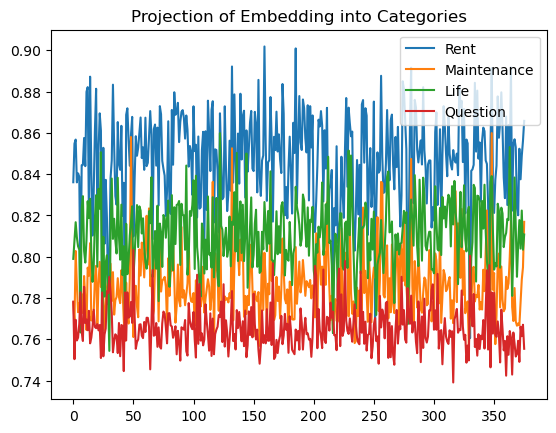

In [19]:
# Look at simple projections
proj_emb = chats_embedding @ category_ex_embedding.T
plt.clf()
plt.plot(proj_emb)
plt.legend(category_def)
plt.title("Projection of Embedding into Categories")
plt.savefig("figures/proj_to_categories")
plt.show()


#### COSINE SIMILARITY ANALYSIS

Cosine similarity is used for its popularity in semantic closeness. The Cosine similarity is computed between each sentence in the dataset and each category sentence example. Results are mostly rent and the results are saved into `'category_predictions.csv'`.

In [12]:
### FINAL CATEGORIZATION ###
category_df = chats_norenew[['resident_id']].copy()

# Calculate and categorize using cosine similarity - This selects the category index for each chat sentence.
category_idx = categorize_cosine_similarity(chats_embedding, category_ex_embedding)
category_def_arr = np.array(category_def)
category_df['reason'] = category_def_arr[category_idx]

print("--- TOTAL CATEGORY COUNT ---")
print(category_df['reason'].value_counts())
final_chats = chats.merge(category_df, on = 'resident_id')
final_chats.head()
final_chats[['resident_id', 'unit_number', 'user_msgs', 'renewal_decision', 'reason']].to_csv('category_predictions.csv', index = False)


--- TOTAL CATEGORY COUNT ---
reason
Rent           363
Life             6
Question         5
Maintenance      2
Name: count, dtype: int64


In [22]:
for reason in category_def:
    if reason == "Rent":
        continue
    print(f"Chats belonging to {reason}:")
    for msg in final_chats[final_chats['reason'] == reason]['user_msgs']:
        print(f"\t{msg}")

Chats belonging to Maintenance:
	["Hey, what's good? Can you hit me with the 411 on them 12-month renewals? Price, all that."]
	['What 12-month renewal options are there?']
Chats belonging to Life:
	["Hi Elise, thanks for checking in with me. I've been thinking about it, but haven't quite come to a final decision yet. Still weighing my options, I guess.", "I guess one thing I've been thinking about is the change in rent. And, to be honest, a couple of things around maintenance have been on my mind. I just want to make sure wherever I end up is both comfortable and makes sense financially."]
	["Hi Elise, thanks for reaching out. I have been thinking about my plans, and honestly, I don't think renewing is going to be the right choice for me this time.", "Well, to be honest, there are a couple things. The rent increase is a bit more than I can handle at the moment, plus there have been some changes with my job that are leading me to consider something a bit different. It's not an easy dec